In [8]:
import sqlite3                                      #sqlite is python built in library for interacting with sql databases
import pandas as pd                                 #pandas is used to load data into the database and to read query results out of the databse
import matplotlib.pyplot as plt                     #is a submodule of matplotlib used to create charts
import warnings                                     #suppress non-critical warning messages that clutter output
warnings.filterwarnings('ignore')
print("successfully imported all the libararies !!!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")



successfully imported all the libararies !!!
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [10]:
df=pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape}")
print(f"Dataset columns: {df.columns}")
print(f"First 3 elements: {df.head(3)}")

Dataset loaded: (30, 13)
Dataset columns: Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')
First 3 elements:    student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            20

**sqlite3.connect()**-creates or opens a db file
**conn**-is the connection object-our link to the db
**cursor**-is the total that executes sql commands
**df.to_sql()** writes the dataframes as a databse table

In [13]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False

)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Databse 'college.db' created succesfully")
print(f"Table 'students' has {count} rows")

Databse 'college.db' created succesfully
Table 'students' has 30 rows


In [18]:
cursor.execute("PRAGMA table_info(students)")
colums_info=cursor.fetchall()
print("Table structure of 'students':")
print(f"{'Column Name':<25}{'Data Type':<12}")
for column in colums_info:
    print(f"{column[1]:<25}{column[2]:<12}")


Table structure of 'students':
Column Name              Data Type   
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


SELECT column1,column2                   --------which columns to show
FROM   table_name                        --------which table to read from
WHERE condition                         ----------filter rows
group by column                         ----------filter columns
having group_condition                 -----------filter groups
order by column desc                   -----------sort results
limit 10                               -----------max rows t0 return

In [24]:
def run_query(sql, description=""):
    if description:
        print(description)

    result = pd.read_sql_query(sql, conn)
    print(result)
print("successs!!!")


successs!!!


In [32]:
query = """
SELECT name, math_score, science_score, programming_score, english_score
FROM (
    SELECT student_id, name, math_score, science_score,
           programming_score, english_score
    FROM students
    ORDER BY student_id DESC
    LIMIT 5
)
ORDER BY student_id ASC;
"""
result = pd.read_sql_query(query, conn)
print(result)

             name  math_score  science_score  programming_score  english_score
0      Rekha Nair          72             77                 63             73
1   Gaurav Shukla          84             79                 87             75
2   Sunita Pillai          60             65                 39             68
3      Nitin Jain          75             76                 50             70
4  Akanksha Yadav          91             93                 94             87


In [37]:
query = """
SELECT name, programming_score
FROM students
WHERE programming_score > 50 AND programming_score < 75
ORDER BY student_id ASC;
"""

result = pd.read_sql_query(query, conn)

print(result)

            name  programming_score
0    Rohit Verma                 55
1    Meera Joshi                 52
2    Vikram Iyer                 72
3  Kavya Nambiar                 51
4   Ritu Agarwal                 69
5  Harish Pillai                 58
6  Preeti Saxena                 53
7     Rekha Nair                 63


In [42]:
q5 = """
SELECT department,
MAX(programming_score) AS top_programming_score
FROM students
WHERE department IN ('Electronics', 'Mechanical', 'Computer Science')
GROUP BY department order by programming_score desc limit 1;
"""

res5 = run_query(q5,"Query 5 : Department with top programming score")

Query 5 : Department with top programming score
         department  top_programming_score
0  Computer Science                     97


In [44]:
query = """
SELECT name, department, attendance_percentage
FROM students
WHERE NOT attendance_percentage <= 80
ORDER BY attendance_percentage ASC;
"""

result = pd.read_sql_query(query, conn)

print(result)

              name        department  attendance_percentage
0       Rekha Nair       Electronics                     82
1      Vikram Iyer       Electronics                     83
2       Nitin Jain        Mechanical                     84
3      Kiran Kumar             Civil                     85
4    Preeti Saxena        Mechanical                     86
5      Priya Patel  Computer Science                     87
6    Gaurav Shukla  Computer Science                     87
7       Suresh Rao  Computer Science                     88
8     Nisha Kapoor  Computer Science                     89
9       Arjun Nair  Computer Science                     90
10   Kavya Nambiar        Mechanical                     91
11       Amit Bose  Computer Science                     91
12    Aarav Sharma  Computer Science                     92
13    Ritu Agarwal       Electronics                     93
14  Swati Kulkarni  Computer Science                     94
15     Sneha Reddy        Mechanical    

In [10]:
dept_data = {
    'dept_code': ['CS', 'EC', 'ME', 'CE'],
    'dept_name': ['Computer Science','Electronics','Mechanical','Cyber Security'],
    'dept_head': ['Arun','Ajay','Hari','Balaji'],
    'year': [1985, 1000, 1999, 2025],
    'intake': [10, 20, 30, 40]
}
dept_df = pd.DataFrame(dept_data)

print(df)

  dept_code         dept_name dept_head  year  intake
0        CS  Computer Science      Arun  1985      10
1        EC       Electronics      Ajay  1000      20
2        ME        Mechanical      Hari  1999      30
3        CE    Cyber Security    Balaji  2025      40


In [13]:
import sqlite3
import pandas as pd

# Create connection
conn = sqlite3.connect("college.db")

In [24]:

dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table: ")
print(dept_df.to_string(index=False))

dept_map = {
    'CS': 'Computer Science',
    'EC': 'Electronics',
    'ME': 'Mechanical',
    'CE': 'Civil'
    }

dept_df['dept_name'] = dept_df['dept_code'].map(dept_map)

print(dept_df)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)

Created 'departments' table: 
dept_code        dept_name dept_head  year  intake
       CS Computer Science      Arun  1985      10
       EC      Electronics      Ajay  1000      20
       ME       Mechanical      Hari  1999      30
       CE            Civil    Balaji  2025      40
  dept_code         dept_name dept_head  year  intake
0        CS  Computer Science      Arun  1985      10
1        EC       Electronics      Ajay  1000      20
2        ME        Mechanical      Hari  1999      30
3        CE             Civil    Balaji  2025      40


4

In [25]:
query = "PRAGMA table_info(students);"

print(pd.read_sql_query(query, conn))

   cid       name     type  notnull dflt_value  pk
0    0  dept_code     TEXT        0       None   0
1    1  dept_name     TEXT        0       None   0
2    2  dept_head     TEXT        0       None   0
3    3       year  INTEGER        0       None   0
4    4     intake  INTEGER        0       None   0


In [26]:
query = "PRAGMA table_info(departments);"

print(pd.read_sql_query(query, conn))

   cid       name     type  notnull dflt_value  pk
0    0  dept_code     TEXT        0       None   0
1    1  dept_name     TEXT        0       None   0
2    2  dept_head     TEXT        0       None   0
3    3       year  INTEGER        0       None   0
4    4     intake  INTEGER        0       None   0


In [32]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

print(pd.read_sql_query(query, conn))

          name
0     students
1  departments


fig,ax=plt.subplot(figsize=(width,height))  -> ceate canvas
ax.bar(x,y)                                 ->draw the chart
ax.set_title('...')                          ->add title
ax.set_xlabel()                             ->label x axis
ax.set_ylabel()                             ->label y axis
plt.tight_layout()                          ->fix label clipping
plt.show()                                  ->display the graph


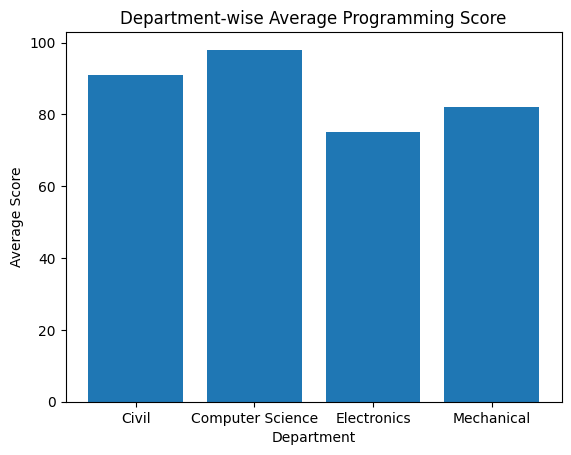

In [39]:
query = """
SELECT department,
       AVG(programming_score) AS avg_score
FROM students
GROUP BY department;
"""
result = pd.read_sql_query(query, conn)
plt.bar(
    result['department'],
    result['avg_score']
)
plt.title("Department-wise Average Programming Score")
plt.xlabel("Department")
plt.ylabel("Average Score")
plt.show()

         department  programming_score
0  Computer Science                 98
1       Electronics                 75
2        Mechanical                 82
3             Civil                 91


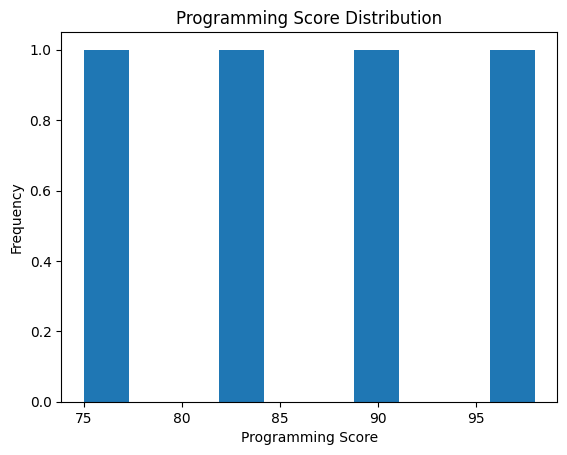

In [42]:
query = """
SELECT department,
       programming_score
FROM students;
"""
result = pd.read_sql_query(query, conn)
print(result)
plt.hist(result['programming_score'])
plt.title("Programming Score Distribution")
plt.xlabel("Programming Score")
plt.ylabel("Frequency")

plt.show()

         department  avg_score
0             Civil       91.0
1  Computer Science       98.0
2       Electronics       75.0
3        Mechanical       82.0


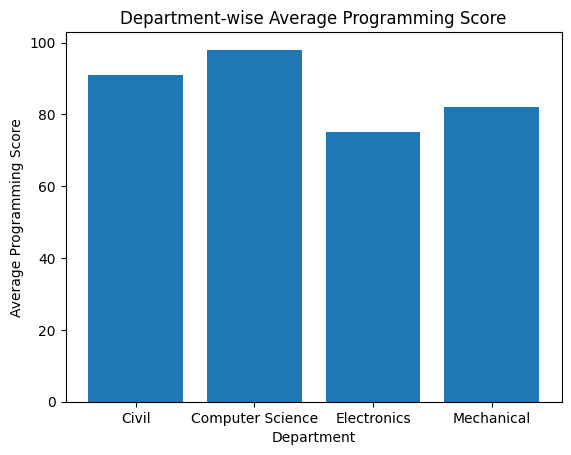

In [44]:
query = """
SELECT department, AVG(programming_score) AS avg_score
FROM students
GROUP BY department;
"""

df = pd.read_sql_query(query, conn)

print(df)

plt.bar(df['department'], df['avg_score'])

plt.xlabel("Department")
plt.ylabel("Average Programming Score")
plt.title("Department-wise Average Programming Score")

plt.show()

         department  programming_score
0  Computer Science                 98
1       Electronics                 75
2        Mechanical                 82
3             Civil                 91


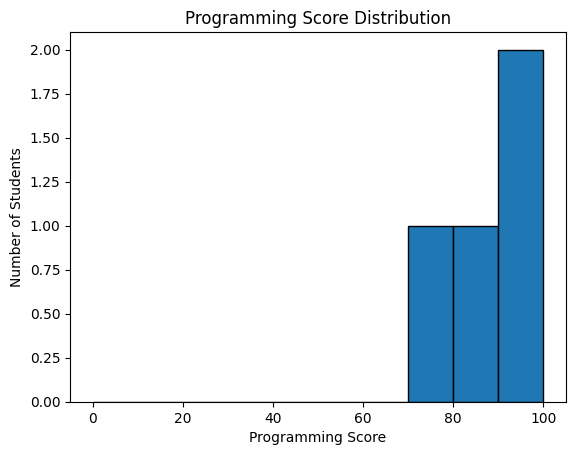

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

query = """
SELECT department, programming_score
FROM students;
"""

df = pd.read_sql_query(query, conn)

print(df)

plt.hist(df['programming_score'], bins=range(0, 101, 10), edgecolor='black')

plt.xlabel("Programming Score")
plt.ylabel("Number of Students")
plt.title("Programming Score Distribution")

plt.show()